In [1]:
import jax
import jax.numpy as jnp

jax.config.update('jax_enable_x64', True)

In [2]:
from functools import partial
from pathlib import Path

import astropy.units as u
import croissant as cro
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse.linalg as sla
from astropy.time import Time

import mistsim as ms

%matplotlib widget

## 1. Define simulation

In [3]:
DATA_DIR = Path(
    "/home/christian/Documents/research/MIST/mistsim/data/"
)

# sky
d = np.load(DATA_DIR / Path("haslam_galactic.npz"))
nside = d["nside"].item()
haslam_onefreq = d["m"][-1]
f = d["freqs"][-1]
print(f)

def scale_map(m, freqs, beta=-2.55, f0=408, tcmb=2.725):
    scale = (freqs/f0)**beta
    return (m-tcmb)[None, :] * scale[:, None] + tcmb

freqs = np.arange(25, 126)
haslam = scale_map(haslam_onefreq, freqs, f0=f)
print(haslam.shape, nside)

# this is the frequency of the simulation
FREQ_IX = 0
sim_freq = freqs[FREQ_IX]
print(f"Simulation frequency = {sim_freq:.0f} MHz")

sky_map = haslam[FREQ_IX]
sky = ms.Sky(sky_map[None], sim_freq, sampling="healpix", coord="galactic")

# forward sim params
tstart = Time("2026-02-25 12:27")
tend = tstart + 1*u.sday  # one sidereal day
times = cro.utils.time_array(t_start=tstart, t_end=tend, N_times=500)
lmax = 179  # theoretical max

# create x vector
sky_alm = sky.compute_alm_eq(world="earth")
sky_alm = cro.utils.reduce_lmax(sky_alm, lmax)
x = ms.mapmaking.pack_s2fft_to_real(sky_alm)

125.0
(101, 196608) 128
Simulation frequency = 25 MHz


In [4]:
def alm1d_to_hp(alm):
    """
    Convert alm 1d with real/imag parts to healpy ordering
    """
    s = len(alm)  # one freq only for now
    lmax = int(np.sqrt(s) - 1)
    hp_len = hp.Alm.getsize(lmax)
    alm0 = alm[:lmax+1]
    almre = alm[lmax+1:hp_len]
    almim = alm[hp_len:]
    almc = 1/np.sqrt(2) * (almre + 1j*almim)
    return jnp.concatenate((alm0, almc))

x_hp = alm1d_to_hp(x)

In [ ]:
LDIR = DATA_DIR / "20240806_for_lisa"

# mars beam
d = np.load(LDIR / "csa2022_beam2.npz")
assert np.allclose(d["freqs"], freqs)
gain = d["gain"]
theta = d["theta"]
horizon = theta <= np.deg2rad(80)  # mountains
g = gain[FREQ_IX]
mars_beam = ms.Beam(
    g[None],
    sim_freq,
    sampling="mwss",
    horizon=horizon[:, None],
    beam_az_rot=10,
)

# nevada beam
d = np.load(LDIR / "jackpot_beam2.npz")
assert np.allclose(d["freqs"], freqs)
gain = d["gain"]
theta = d["theta"]
g = gain[FREQ_IX]
# no mountain blockage!
nv_beam = ms.Beam(
    g[None], sim_freq, sampling="mwss", horizon=None, beam_az_rot=64
)

# nevada monopole
g = np.sin(theta)**2
# add phi axis
g = np.repeat(g[:, None], 360, axis=-1)
nv_monopole = ms.Beam(
    g[None], sim_freq, sampling="mwss", horizon=None,
)

In [6]:
# mars
lon = -90.74750
lat = 79.41833
alt = 150

sim_mars = ms.Simulator(mars_beam, sky, times.jd, sim_freq, lon, lat, alt=alt, lmax=lmax)
A_mars = ms.mapmaking.make_Amat(sim_mars)

# nevada
lat = 37.21333
lon = -117.09111
alt = 0

sim_nv = ms.Simulator(nv_beam, sky, times.jd, sim_freq, lon, lat, alt=alt, lmax=lmax)
A_nv = ms.mapmaking.make_Amat(sim_nv)

sim_nv_mono = ms.Simulator(nv_monopole, sky, times.jd, sim_freq, lon, lat, alt=alt, lmax=lmax)
A_mono = ms.mapmaking.make_Amat(sim_nv_mono)

In [7]:
def _rmatvec_stack(A1, A2, v):
    m1, n = A1.shape
    m2, n2 = A2.shape
    v1 = v[:m1]
    v2 = v[m1:]
    return A1.rmatvec(v1) + A2.rmatvec(v2)
    
def stack_As(A1, A2):
    """
    Stack A matrices defined by scipy.sparse.linalg.LinearOperator

    Parameters
    ----------
    A1 : LinearOperator
        Shape is (M1, N)
    A2 : LinearOperator
        Shape is (M2, N)
    

    Returns
    -------
    Astack : LinearOperator
        Vertically stacked A1, A2, shape is (M1+M2, N)

    """
    m1, n = A1.shape
    m2, n2 = A2.shape
    if not n == n2:
        raise ValueError("Incompatible shapes")
    shape = (m1+m2, n)
    matvec = lambda v: np.concatenate((A1.matvec(v), A2.matvec(v)), axis=0)
    rmatvec = lambda v: _rmatvec_stack(A1, A2, v)
    Astack = sla.LinearOperator(shape, matvec=matvec, rmatvec=rmatvec)
    return Astack

A_dip = stack_As(A_mars, A_nv)
A = stack_As(A_dip, A_mono)

## 2. Run simulation, define noise and prior

In [8]:
y = A@x

# noise: radiometer
df = (freqs[1] - freqs[0]) * 1e6
dt = (times[1] - times[0]).to_value(u.s)
print(dt * df)
sigma = y.real / np.sqrt(dt * df)
Ndiag = sigma**2  # diag matrix

rng = np.random.default_rng(seed=1420)
noise = rng.normal(loc=0, scale=sigma)

172673528.11623126


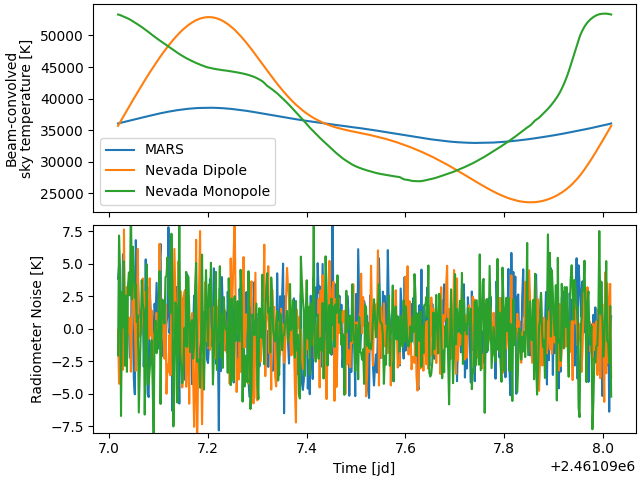

In [9]:
Ntimes = len(times)

fig, axs = plt.subplots(nrows=2, sharex=True, constrained_layout=True)
lines = axs[0].plot(times.jd, (y+noise).reshape(3, Ntimes).T)
axs[1].plot(times.jd, noise.reshape(3, Ntimes).T)
axs[0].set_ylabel("Beam-convolved\nsky temperature [K]")
axs[1].set_ylabel("Radiometer Noise [K]")
axs[1].set_xlabel("Time [jd]")
axs[1].set_ylim(-8, 8)
axs[0].legend(lines, ["MARS", "Nevada Dipole", "Nevada Monopole"])
plt.show()

In [10]:
def prior_ps(x):
    """
    Make prior be the true power spectrum of the sky

    Parameters
    ----------
    x : array_like
        Column vector

    """
    xhp = np.asarray(alm1d_to_hp(x))
    cl = hp.alm2cl(xhp)
    ells_hp, emms_hp = hp.Alm.getlm(lmax)
    ells_pos = ells_hp[emms_hp != 0]
    ells_full = np.concatenate((ells_hp, ells_pos))  # the m>=0 comes twice
    cl_full = cl[ells_full]
    return cl_full

Sdiag = prior_ps(x)
Sdiag.shape

(32400,)

True


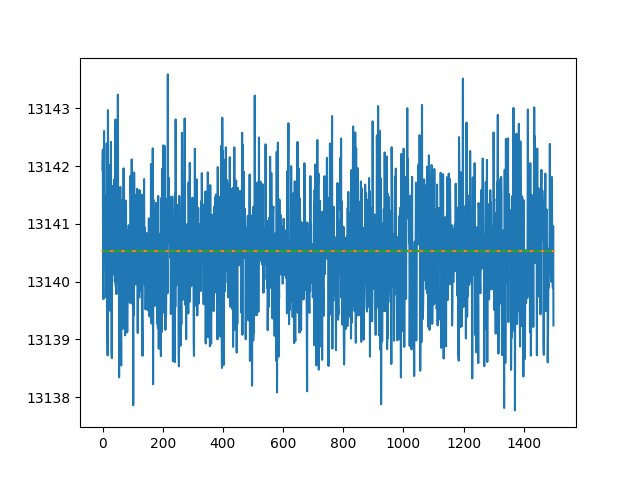

In [11]:
Atilde = ms.mapmaking.make_Atilde(Ndiag, A, Sdiag)
U_full, Sigma, Vh_full = sla.svds(Atilde, k=1200)
#Atilde_dense = np.eye(Atilde.shape[0]) @ Atilde @ np.eye(Atilde.shape[1])
#U_full, Sigma, Vh_full = svd(Atilde_dense, full_matrices=True)

# sort the u, s, v
svd_ix = np.argsort(Sigma)[::-1]
U_full = U_full[:, svd_ix]
Sigma = Sigma[svd_ix]
Vh_full = Vh_full[svd_ix]

xtilde = Sdiag**(-1/2) * x
ytilde = Ndiag**(-1/2) * y
ntilde = Ndiag**(-1/2) * noise

# confirm we got Ax = y still
print(np.allclose(Atilde @ xtilde, ytilde))

plt.figure()
plt.plot(ytilde+ntilde)
plt.plot(ytilde)
plt.plot(Atilde@xtilde, ls="--")
plt.show()

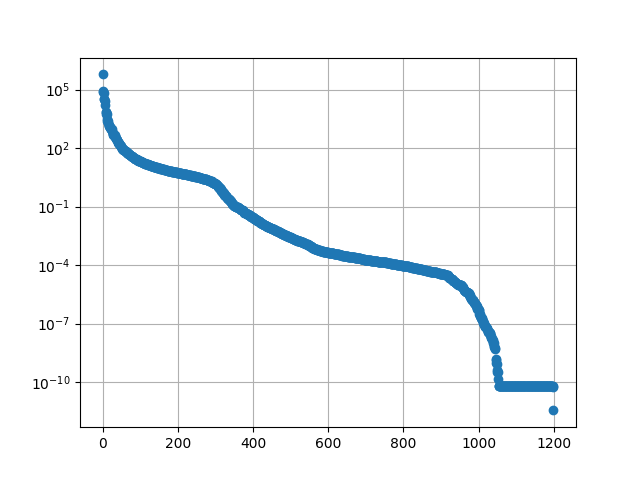

In [12]:
plt.figure()
plt.plot(Sigma, ls="none", marker="o")
plt.yscale("log")
plt.grid()
plt.show()

1.4094696160590087e-10 5.940984499221724e-11


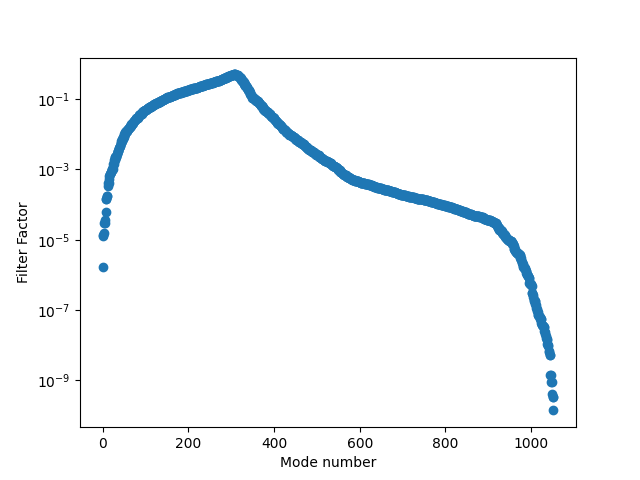

In [13]:
nvec = 1053
print(Sigma[nvec-1], Sigma[nvec])
Dnum = Sigma[:nvec]
Dden = 1 + Dnum**2
D = Dnum / Dden
U = U_full[:, :nvec]
Vh = Vh_full[:nvec]

plt.figure()
plt.plot(np.arange(nvec), D[:nvec], ls="none", marker="o")
plt.ylabel("Filter Factor")
plt.xlabel("Mode number")
plt.yscale("log")
plt.show()

In [14]:
W_tilde = Vh.T @ np.diag(D) @ U.T  # VDU^T
y_tilde = Ndiag**(-1/2) * (y+noise)
x_tilde = W_tilde @ y_tilde
xh_svd = Sdiag**(1/2) * x_tilde
xh_svd_hp = alm1d_to_hp(xh_svd)

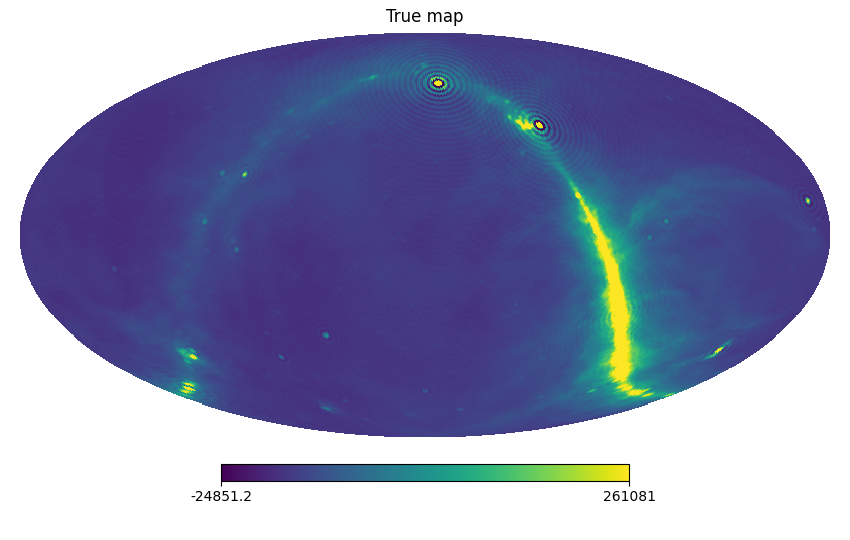

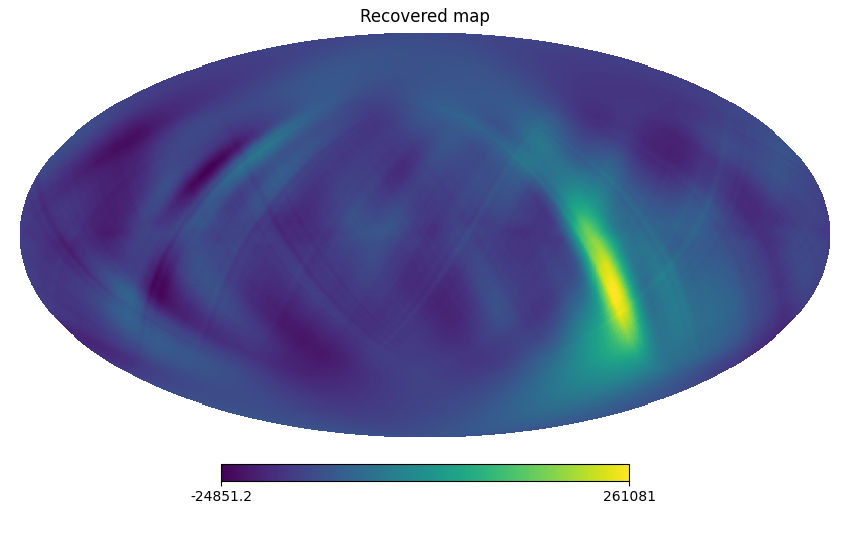

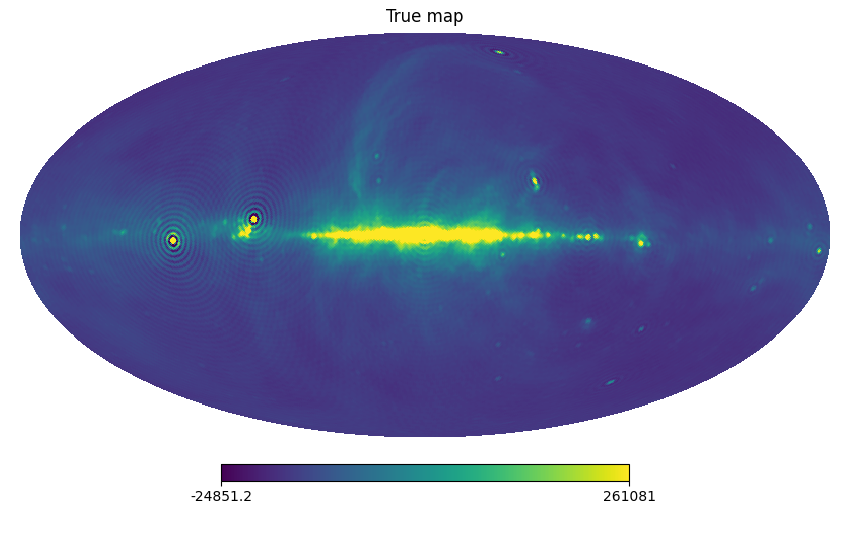

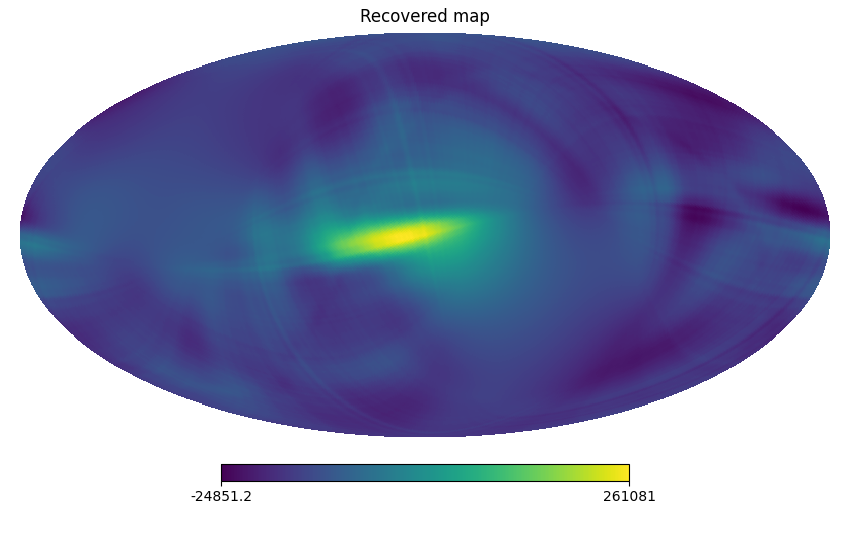

In [59]:
true_map = hp.alm2map(x_hp, nside)
best_map = hp.alm2map(xh_svd_hp, nside)
vmin = best_map.min()
vmax = best_map.max()
#vmax = 52732.3
#vmax = 4.39925e6

hp.mollview(true_map, title="True map", min=vmin, max=vmax)
plt.show()
hp.mollview(best_map, title="Recovered map", min=vmin, max=vmax)
plt.show()

rot = hp.Rotator(coord="cg")
#true_hp_gal = hp.alm2map(rot.rotate_alm(x_hp), nside)
#best_hp_gal = hp.alm2map(rot.rotate_alm(xh_svd_hp), nside)
true_hp_gal = rot.rotate_map_alms(true_map, lmax=lmax)
best_hp_gal = rot.rotate_map_alms(best_map, lmax=lmax)

hp.mollview(true_hp_gal, title="True map", min=vmin, max=vmax)
plt.show()
hp.mollview(best_hp_gal, title="Recovered map", min=vmin, max=vmax)
plt.show()

In [29]:
nvar = 1000

# generate 1000 random alm's
wfull = np.random.normal(size=(Atilde.shape[1], nvar))  # variance = 1

# compute the posterior standard deviation in the SVD basis
post_std_svd = 1.0 / np.sqrt(Dnum**2 + 1.0)  # 1/(sigma**2+1)
std_reduce = 1 - post_std_svd  # this is reduced variance in posterior

# compute reduced-variance noise
corr = Vh.T @ (std_reduce[:, None] * (Vh @ wfull))
x_tilde_sim = wfull - corr  # subtract corection

# back to harmonic coefficients
x_sim = np.sqrt(Sdiag)[:, None] * x_tilde_sim
x_sim_hp = np.array(
    [alm1d_to_hp(x_sim[:, i]) for i in range(x_sim.shape[-1])]
)
x_sim_map = np.array([hp.alm2map(xs, nside) for xs in x_sim_hp])

# posterior std
std_alm_re = np.std(x_sim_hp.real, axis=0)
std_alm_im = np.std(x_sim_hp.imag, axis=0)
std_alm_com = std_alm_re + 1j * std_alm_im
std_alm = np.sqrt(std_alm_re**2 + std_alm_im**2)
std_map = np.std(x_sim_map, axis=0)

# prior power spectrum
cl_prior = hp.alm2cl(np.asarray(x_hp))
ell = np.arange(len(cl_prior))
sigma2_prior = np.sum((2 * ell + 1) / (4 * np.pi) * cl_prior)
print(f"Prior standard deviation = {np.sqrt(sigma2_prior):.1f} K")

Prior standard deviation = 62440.3 K


In [1]:
np.savez("results/mars-dip_nv-mono-dip.npz", freqs=freqs, lmax=lmax, x_true=x_hp, x_rec=xh_svd_hp, cl_prior=cl_prior, sigma2_prior=sigma2_prior, std_alm=std_alm_com)

NameError: name 'np' is not defined

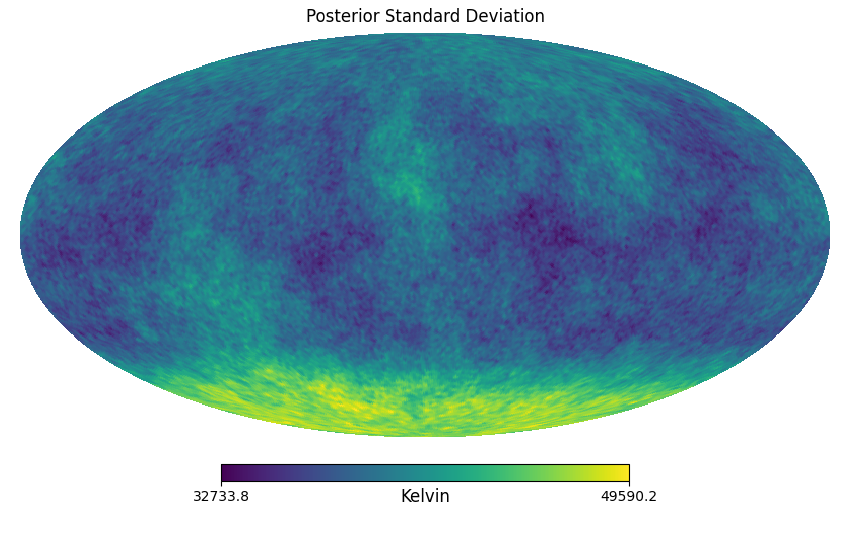

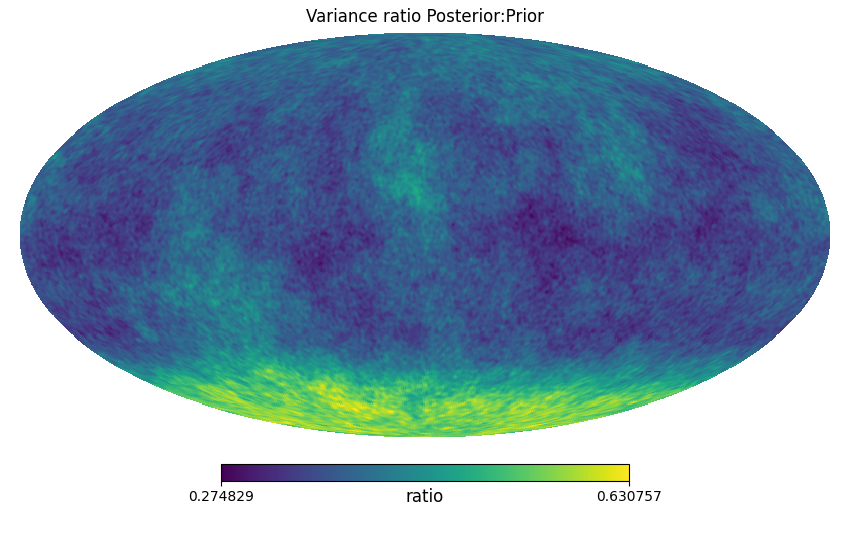

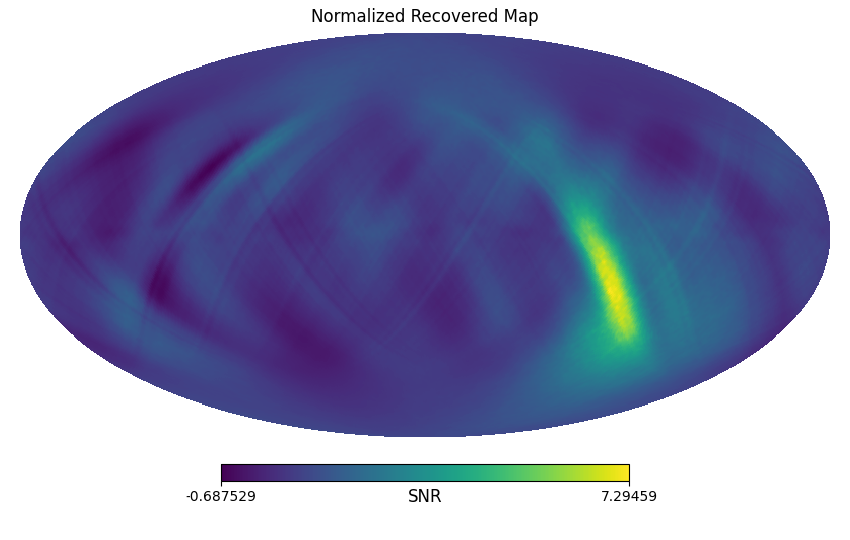

In [22]:
hp.mollview(std_map, title="Posterior Standard Deviation", unit="Kelvin")
plt.show()
hp.mollview(
    std_map**2/sigma2_prior,
    title="Variance ratio Posterior:Prior",
    unit="ratio",
)
plt.show()
hp.mollview(best_map/std_map, title="Normalized Recovered Map", unit="SNR")
plt.show()

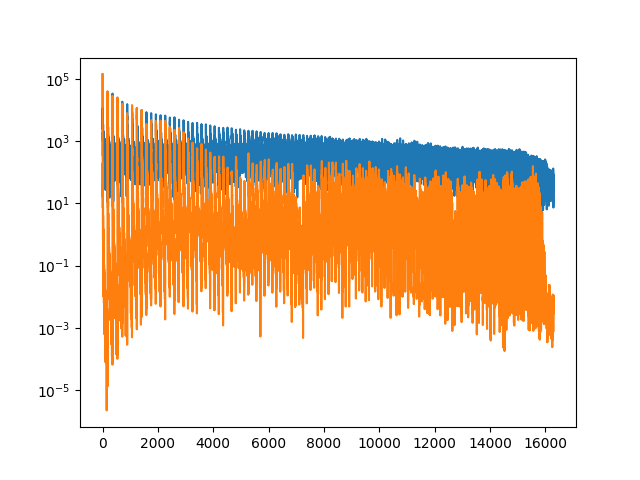

In [23]:
plt.figure()
plt.plot(np.abs(x_hp), label="True")
plt.plot(np.abs(xh_svd_hp), label="Recovered")
plt.yscale("log")
plt.show()

In [27]:
def plot_alm_comparison(x_true, x_rec, std_alm, lmax_intrinsic, lmax_plot=5):
    """
    Plots true vs recovered a_lm coefficients with error bars up to a small lmax.
    
    Parameters:
    -----------
    x_true : array-like complex
        The true a_lm array in standard Healpy ordering.
    x_rec : array-like complex
        The recovered a_lm array in standard Healpy ordering.
    std_alm : array-like complex
        The error bars. Assuming std_alm.real is the error on the real part, 
        and std_alm.imag is the error on the imaginary part.
    lmax_intrinsic : int
        The actual lmax used to generate/store the full 1D healpy arrays.
    lmax_plot : int
        The maximum l to include in this visualization (keep small, e.g., <= 10).
    """
    
    # Lists to store the naturally-ordered data
    labels = []
    
    true_real, rec_real, err_real = [], [], []
    true_imag, rec_imag, err_imag = [], [], []
    
    # Loop over l first, then m for an intuitive (l, m) grouping
    for l in range(lmax_plot + 1):
        for m in range(l + 1):
            # Fetch the actual 1D array index for this (l, m) pair
            idx = hp.Alm.getidx(lmax_intrinsic, l, m)
            
            labels.append(f"({l},{m})")
            
            # Extract Real parts
            true_real.append(x_true[idx].real)
            rec_real.append(x_rec[idx].real)
            err_real.append(std_alm[idx].real)
            
            # Extract Imaginary parts (m=0 is purely real, so imag=0)
            if m > 0:
                true_imag.append(x_true[idx].imag)
                rec_imag.append(x_rec[idx].imag)
                err_imag.append(std_alm[idx].imag)
            else:
                true_imag.append(0.0)
                rec_imag.append(0.0)
                err_imag.append(0.0)

    # Convert to numpy arrays for plotting
    x_indices = np.arange(len(labels))
    true_real, rec_real, err_real = map(np.array, [true_real, rec_real, err_real])
    true_imag, rec_imag, err_imag = map(np.array, [true_imag, rec_imag, err_imag])

    # --- Plotting ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, constrained_layout=True)
    
    # Plot Real Part
    ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax1.plot(x_indices, true_real, 'ks', markersize=6, label='True (Real)')
    ax1.errorbar(x_indices, rec_real, yerr=err_real, fmt='ro', 
                 markersize=5, capsize=3, label='Recovered (Real)')
    ax1.set_ylabel(r'$\mathrm{Re}(a_{\ell m})$', fontsize=14)
    ax1.set_title(r'Spherical Harmonic Coefficients True vs Recovered ($\ell_{\mathrm{max}} = %d$)' % lmax_plot, fontsize=16)
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Plot Imaginary Part
    ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax2.plot(x_indices, true_imag, 'ks', markersize=6, label='True (Imag)')
    ax2.errorbar(x_indices, rec_imag, yerr=err_imag, fmt='bo', 
                 markersize=5, capsize=3, label='Recovered (Imag)')
    ax2.set_ylabel(r'$\mathrm{Im}(a_{\ell m})$', fontsize=14)
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # Formatting the x-axis with our custom (l, m) labels
    ax2.set_xticks(x_indices)
    ax2.set_xticklabels(labels, rotation=60, ha='right', fontsize=10)
    ax2.set_xlabel(r'$(\ell, m)$ indices', fontsize=14)
    
    # Highlight l-transitions with light vertical lines
    l_transitions = [i for i, label in enumerate(labels) if label.endswith(',0)')]
    for transition in l_transitions:
        ax1.axvline(transition - 0.5, color='gray', linestyle=':', alpha=0.5)
        ax2.axvline(transition - 0.5, color='gray', linestyle=':', alpha=0.5)

    plt.show()

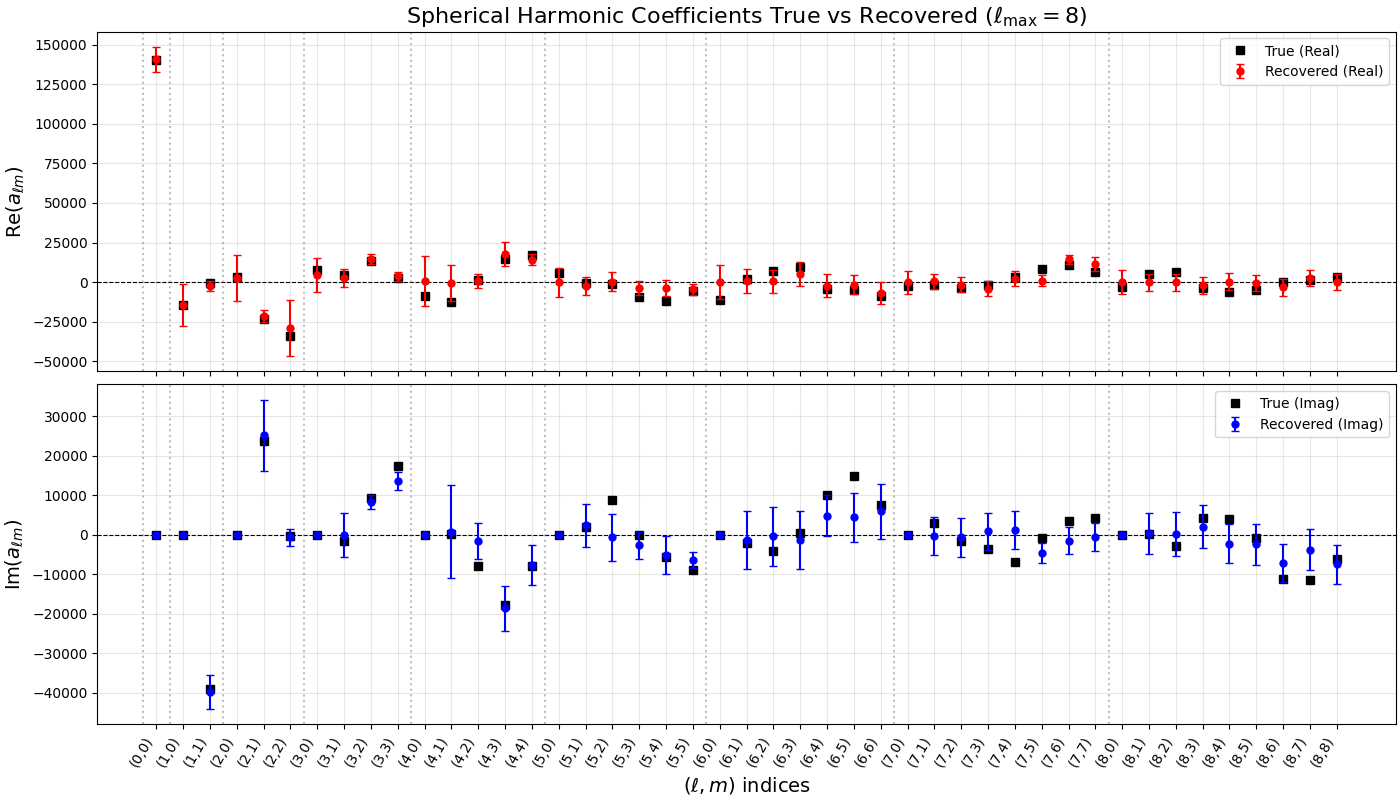

In [54]:
plot_alm_comparison(x_hp, xh_svd_hp, std_alm_com, lmax, lmax_plot=8)

In [36]:
def plot_alm_heatmap_residuals(x_true, x_rec, std_total, lmax):
    """
    Plots a 2D heatmap of the normalized residuals: |True - Recovered| / Error
    """
    # 1. Get the l and m arrays for the entire 1D healpy array
    l_arr, m_arr = hp.Alm.getlm(lmax)
    
    # 2. Calculate the metric you want to visualize
    # Here, we use the absolute error normalized by your total error bar
    diff = np.abs(x_true - x_rec)
    normalized_residual = diff / std_total
    
    # 3. Create an empty 2D matrix filled with NaNs (shape: lmax+1, lmax+1)
    # NaNs ensure the empty half of the square (where m > l) doesn't plot
    matrix2d = np.full((lmax + 1, lmax + 1), np.nan)
    
    # 4. Map the 1D array into the 2D matrix using advanced indexing
    matrix2d[l_arr, m_arr] = normalized_residual

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Use a colormap and set the 'bad' (NaN) values to white or gray
    cmap = plt.cm.viridis
    cmap.set_bad(color='white')
    
    # Plot the heatmap (origin='upper' puts l=0 at the top, standard for matrices)
    im = ax.imshow(matrix2d, cmap=cmap, origin='upper', 
                   vmax=np.nanpercentile(normalized_residual, 99)) # cap color at 99th percentile
    
    ax.set_title('Normalized Residuals: $|a_{\\ell m}^{\\mathrm{true}} - a_{\\ell m}^{\\mathrm{rec}}| / \\sigma$', fontsize=16)
    ax.set_ylabel('Multipole $\\ell$', fontsize=14)
    ax.set_xlabel('Azimuthal number $m$', fontsize=14)
    
    # Add a diagonal line showing the m = l boundary
    ax.plot([0, lmax], [0, lmax], 'k--', alpha=0.5, label=r'$m = \ell$ boundary')
    ax.legend(loc='upper right')
    
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Residual / $\\sigma$', fontsize=14)
    
    plt.show()

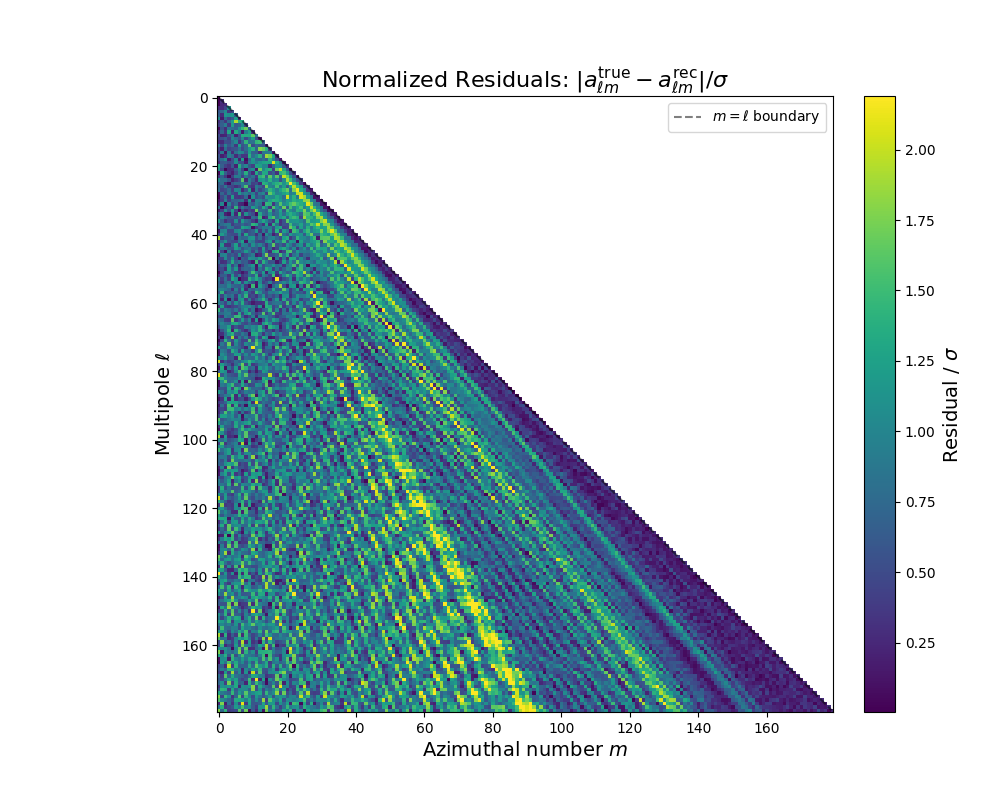

In [37]:
plot_alm_heatmap_residuals(x_hp, xh_svd_hp, std_alm, lmax)

In [52]:
def plot_power_spectra(x_true, x_rec, std_alm):
    """
    Computes and plots the angular power spectra (C_l) for true, recovered, 
    and the theoretical noise from error bars.
    """
    
    # 1. Compute Power Spectra using Healpy
    # hp.alm2cl handles the 1/(2l+1) normalization and the m>0 symmetries automatically
    cl_true = hp.alm2cl(x_true)
    cl_rec  = hp.alm2cl(x_rec)
    
    # 2. Compute Noise Power Spectrum (N_l)
    # By passing the complex error array, this computes the average variance per l
    nl_err = hp.alm2cl(std_alm)
    
    # 3. Compute the Cross-Spectrum (True x Recovered)
    # This checks phase-alignment between the true and recovered maps
    cl_cross = hp.alm2cl(x_true, x_rec)
    
    # Create the multipole array for the x-axis
    l_arr = np.arange(len(cl_true))
    
    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
    
    # Plotting on a log-y scale is standard because power spans many orders of magnitude
    ax.plot(l_arr, cl_true, 'k-', linewidth=2.5, label=r'True Signal ($C_\ell^{\mathrm{true}}$)')
    ax.plot(l_arr, cl_rec, 'b-', linewidth=2, label=r'Recovered Signal ($C_\ell^{\mathrm{rec}}$)')
    ax.plot(l_arr, cl_cross, 'g-.', linewidth=2, label=r'Cross-Spectrum (True $\times$ Rec)')
    ax.plot(l_arr, nl_err, 'r--', linewidth=2, label=r'Error Variance ($N_\ell$)')
    
    # Formatting
    ax.set_yscale('log')
    # If lmax is very large, a log-x scale can also be helpful:
    if len(l_arr) > 100:
        ax.set_xscale('log')
        
    ax.set_xlabel('Multipole $\\ell$', fontsize=14)
    ax.set_ylabel('Power Spectrum $C_\\ell$', fontsize=14)
    ax.set_title('Angular Power Spectra: True vs. Wiener Filtered Recovery', fontsize=16)
    
    ax.legend(fontsize=12, loc='lower left')
    ax.grid(True, which="both", ls=":", alpha=0.6)
    
    # Set x-limits to avoid the l=0 (monopole) if it drops to 0 in log scale
    ax.set_xlim(left=1 if l_arr[-1] > 10 else 0) 
    
    plt.show()

# --- Bonus: The Transfer Function ---
def plot_transfer_function(x_true, x_rec):
    """
    Plots the empirical filter transfer function: C_l^(cross) / C_l^(true)
    For a Wiener filter, this should ideally be close to 1 where S/N is high, 
    and drop to 0 where noise dominates.
    """
    cl_true = hp.alm2cl(x_true)
    cl_cross = hp.alm2cl(x_true, x_rec)
    
    # Avoid division by zero
    valid = cl_true > 0
    transfer = np.zeros_like(cl_true)
    transfer[valid] = cl_cross[valid] / cl_true[valid]
    
    plt.figure(figsize=(8, 4))
    plt.plot(np.arange(len(transfer)), transfer, 'm-', lw=2)
    plt.axhline(1, color='k', ls='--', alpha=0.5)
    plt.xlabel('Multipole $\\ell$')
    plt.ylabel('$C_\\ell^{\\mathrm{cross}} / C_\\ell^{\\mathrm{true}}$')
    plt.title('Wiener Filter Empirical Transfer Function')
    plt.grid(alpha=0.3)
    plt.show()

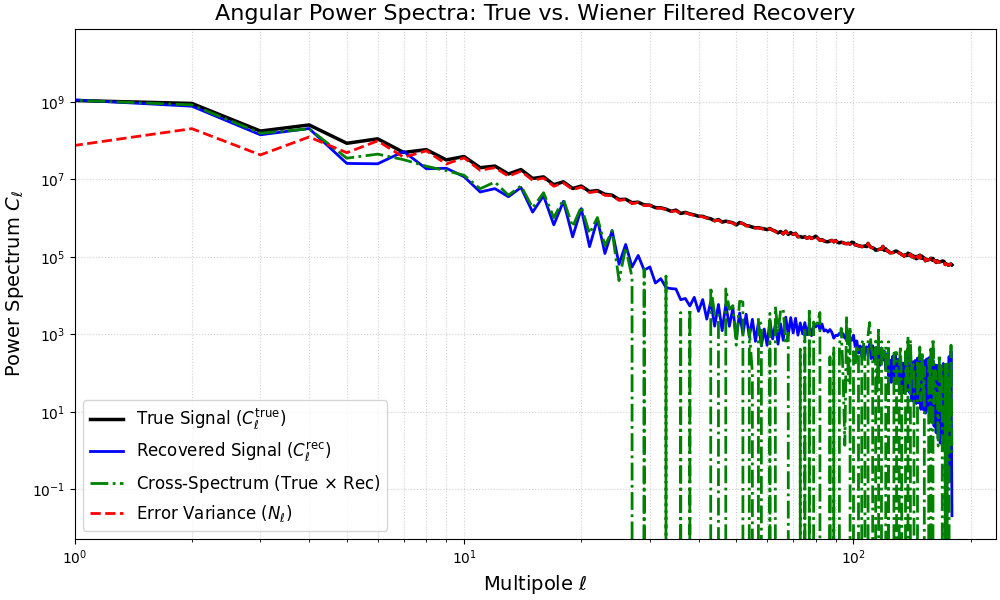

In [53]:
plot_power_spectra(np.asarray(x_hp, dtype=complex), np.asarray(xh_svd_hp, dtype=complex), std_alm_com)

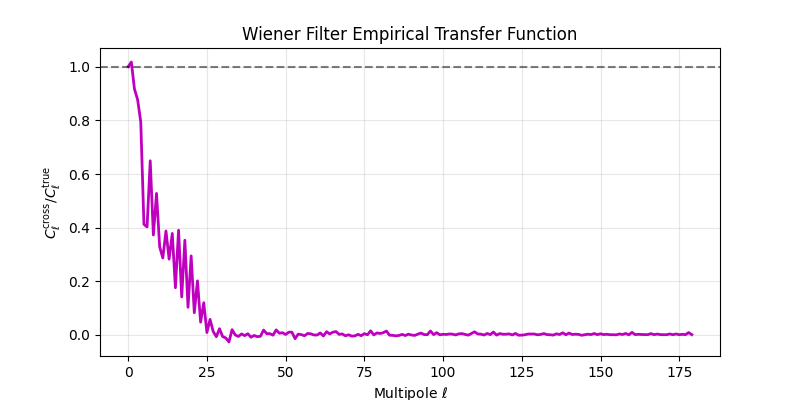

In [49]:
plot_transfer_function(np.asarray(x_hp, dtype=complex), np.asarray(xh_svd_hp, dtype=complex))

In [77]:
def plot_maps_and_residuals(x_true, x_rec, lmax_intrinsic, plot_lmax, nside=128, plot_galactic=False):
    """
    Plots Mollweide projections of the True map, Recovered map, and the Residuals,
    filtered up to plot_lmax. Includes an option to rotate from Equatorial to Galactic.
    """
    
    # 1. Create and apply the low-pass filter
    fl = np.ones(lmax_intrinsic + 1)
    fl[plot_lmax + 1:] = 0.0
    
    x_true_low_l = hp.almxfl(x_true, fl)
    x_rec_low_l  = hp.almxfl(x_rec, fl)
    
    # 2. Transform to maps
    map_true = hp.alm2map(x_true_low_l, nside=nside)
    map_rec  = hp.alm2map(x_rec_low_l, nside=nside)
    
    # 3. Compute Residuals (True - Recovered)
    map_res = map_true - map_rec
    
    # 4. Handle Coordinate Rotations
    # 'C' = Celestial (Equatorial), 'G' = Galactic
    if plot_galactic:
        coord_transform = ['C', 'G'] 
        coord_label = "Galactic"
    else:
        coord_transform = ['C', 'C'] # Keeps it in Equatorial
        coord_label = "Equatorial"

    # --- Plotting ---
    fig = plt.figure(figsize=(10, 10))
    
    # Lock the color limits for True and Recovered so they are visually identical
    vmin = min(map_true.min(), map_rec.min())
    vmax = max(map_true.max(), map_rec.max())
    
    # For residuals, we want a symmetric colorbar strictly centered on zero
    res_max = np.max(np.abs(map_res))
    
    # Panel 1: True Map
    hp.mollview(map_true, sub=(3, 1, 1), 
                title=f'True Map (l <= {plot_lmax})\n[{coord_label}]', 
                cmap='viridis', min=vmin, max=vmax, coord=coord_transform)
                
    # Panel 2: Recovered Map
    hp.mollview(map_rec, sub=(3, 1, 2), 
                title=f'Recovered Map (l <= {plot_lmax})\n[{coord_label}]', 
                cmap='viridis', min=vmin, max=vmax, coord=coord_transform)
                
    # Panel 3: Residual Map
    # Using 'coolwarm' here is great because white = 0 error, red/blue = over/under estimation
    hp.mollview(map_res, sub=(3, 1, 3), 
                title=f'Residual (True - Rec)\n[{coord_label}]', 
                cmap='coolwarm', min=-res_max, max=res_max, coord=coord_transform)
    
    plt.show()

In [84]:
def plot_maps_and_residuals(x_true, x_rec, lmax_intrinsic, plot_lmax, nside=128, plot_galactic=False):
    """
    Plots Mollweide projections in a 3-row layout with vertical colorbars 
    to prevent text overlap.
    """
    
    # 1. Create and apply the low-pass filter
    fl = np.ones(lmax_intrinsic + 1)
    fl[plot_lmax + 1:] = 0.0
    
    x_true_low_l = hp.almxfl(x_true, fl)
    x_rec_low_l  = hp.almxfl(x_rec, fl)
    
    # 2. Transform to maps
    map_true = hp.alm2map(x_true_low_l, nside=nside)
    map_rec  = hp.alm2map(x_rec_low_l, nside=nside)
    map_res  = map_true - map_rec
    
    # 3. Handle Coordinate Rotations
    if plot_galactic:
        coord_transform = ['C', 'G'] 
        coord_label = "Galactic"
    else:
        coord_transform = ['C', 'C']
        coord_label = "Equatorial"

    # --- Plotting ---
    # Make the figure tall and relatively narrow for a 3-row layout
    fig = plt.figure(figsize=(8, 14))
    
    vmin = min(map_true.min(), map_rec.min())
    vmax = max(map_true.max(), map_rec.max())
    res_max = np.max(np.abs(map_res))
    
    # Helper function to add vertical colorbars cleanly
    def add_vertical_colorbar(label=""):
        ax = plt.gca()
        image = ax.get_images()[0]
        cbar = fig.colorbar(image, ax=ax, orientation='vertical', shrink=0.6, pad=0.05)
        cbar.set_label(label, fontsize=12)

    # Panel 1: True Map (Row 1)
    hp.mollview(map_true, sub=(3, 1, 1), cbar=False,
                title=f'True Map (l <= {plot_lmax})',
                cmap='viridis', min=vmin, max=vmax, coord=coord_transform)
    add_vertical_colorbar("Signal Amplitude")
                
    # Panel 2: Recovered Map (Row 2)
    hp.mollview(map_rec, sub=(3, 1, 2), cbar=False,
                title=f'Recovered Map (l <= {plot_lmax})', 
                cmap='viridis', min=vmin, max=vmax, coord=coord_transform)
    add_vertical_colorbar("Signal Amplitude")
                
    # Panel 3: Residual Map (Row 3)
    hp.mollview(map_res, sub=(3, 1, 3), cbar=False,
                title=f'Residual (True - Rec)', 
                cmap='coolwarm', min=-res_max, max=res_max, coord=coord_transform)
    add_vertical_colorbar("Residual Error")
    
    plt.tight_layout()
    plt.show()

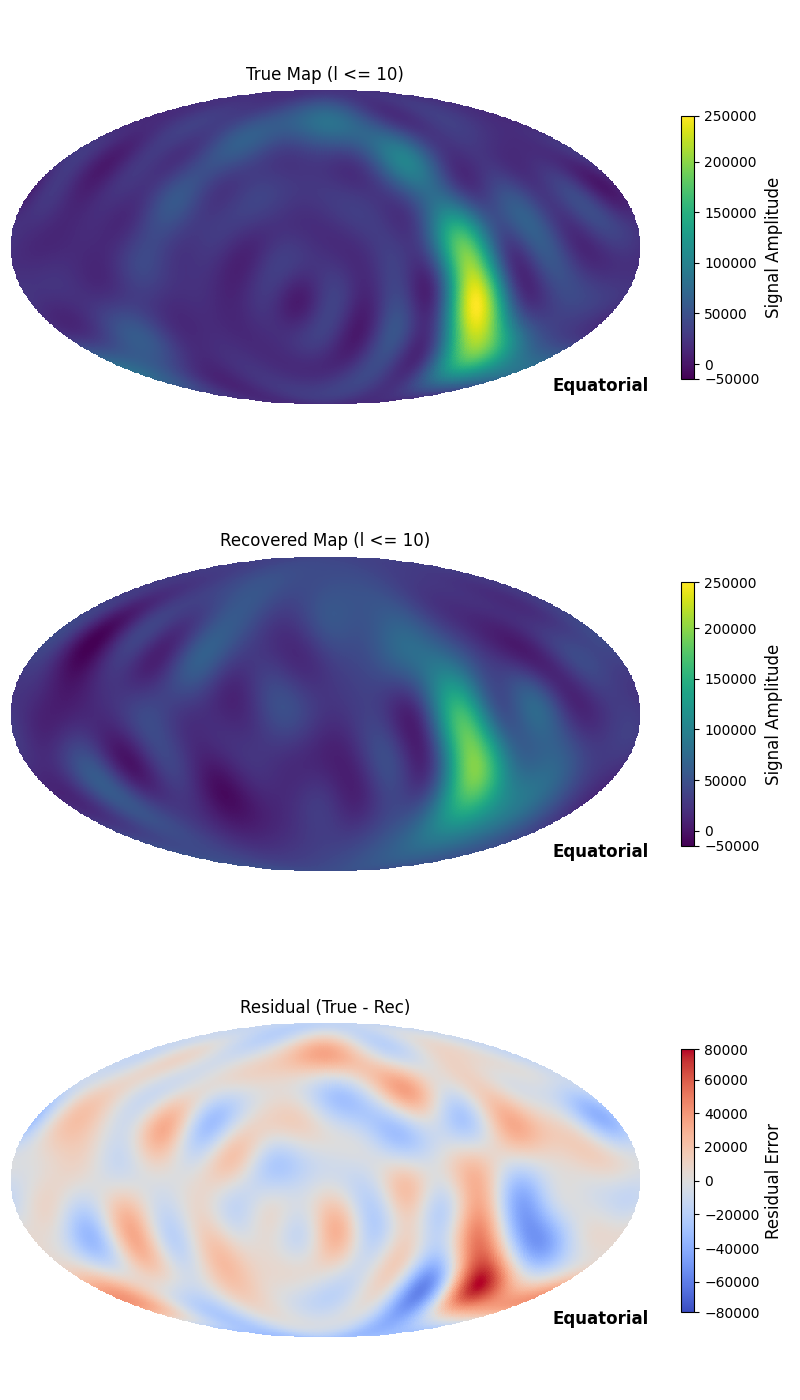

In [85]:
plot_maps_and_residuals(x_hp, xh_svd_hp, lmax, 10)

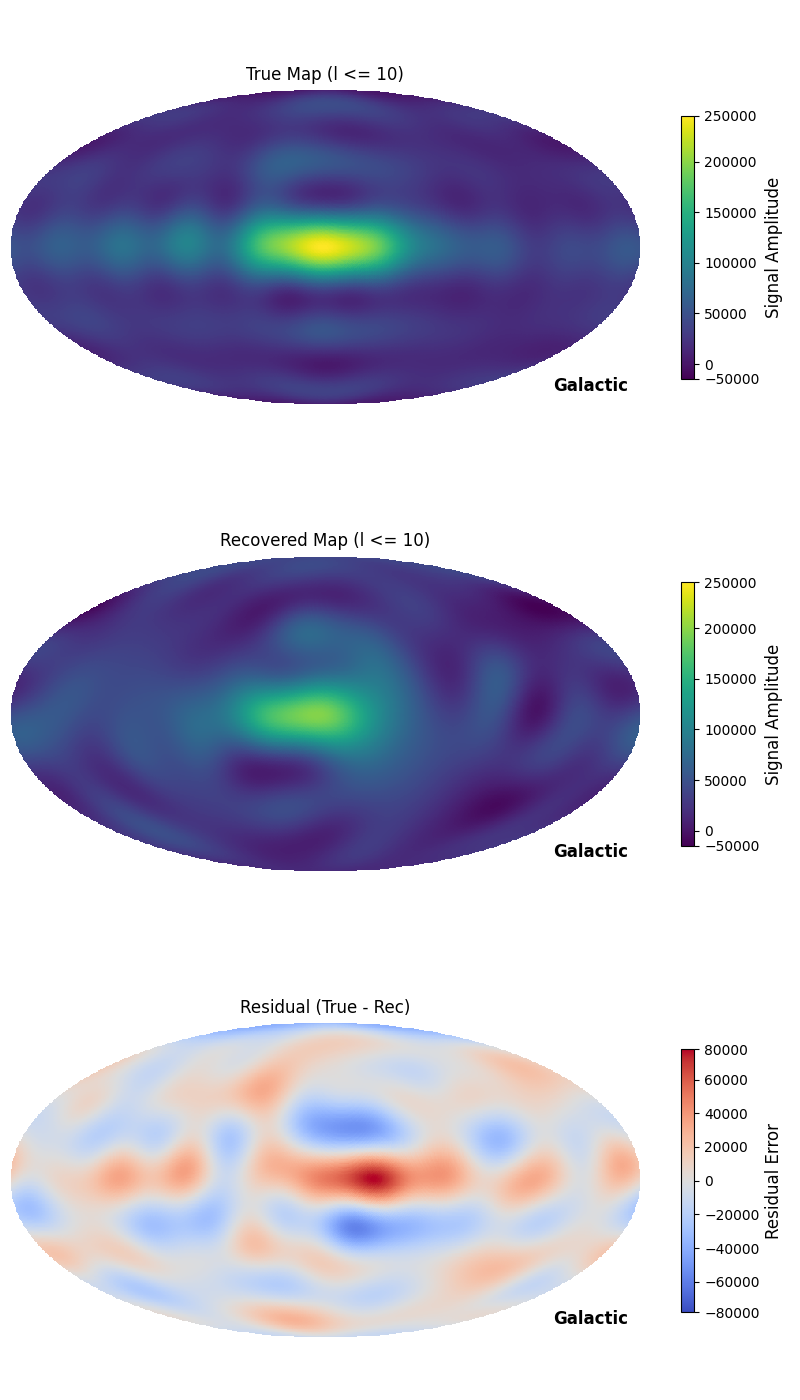

In [86]:
plot_maps_and_residuals(x_hp, xh_svd_hp, lmax, 10, plot_galactic=True)